# Entregable 1 — Champions League
## Definición del problema

**Problema:** falta análisis sistemático que combine datos históricos de la
Champions League con datos de la temporada actual para responder preguntas
concretas sobre desempeño de equipos.

**Pregunta principal:** ¿cómo se compara el desempeño de los equipos en la
temporada actual (fuente API) contra su historial en finales del torneo
(fuente Kaggle)?

**Usuario o interesado:** un analista de contenidos deportivos que decide
qué equipos destacar en cobertura, comparando su forma actual contra su
peso histórico en el torneo.

In [2]:
import sys
sys.path.append("../src")

from extract_api_football_data import fetch_matches

df_api = fetch_matches()
print("Dimensiones:", df_api.shape)
df_api.head()

Dimensiones: (144, 10)


,match_id,season,stage,matchday,utc_date,status,home_team,away_team,home_score,away_score
0,575323,2026,LEAGUE_STAGE,1,2026-09-08T16:45:00Z,FINISHED,Club Brugge KV,Aston Villa FC,2.0,3.0
1,575324,2026,LEAGUE_STAGE,1,2026-09-08T16:45:00Z,FINISHED,PAE AEK,LASK Linz,1.0,0.0
2,575325,2026,LEAGUE_STAGE,1,2026-09-08T19:00:00Z,FINISHED,Real Madrid CF,FC Internazionale Milano,2.0,1.0
3,575326,2026,LEAGUE_STAGE,1,2026-09-08T19:00:00Z,FINISHED,FC Porto,Manchester City FC,0.0,2.0
4,575327,2026,LEAGUE_STAGE,1,2026-09-08T19:00:00Z,FINISHED,Borussia Dortmund,Villarreal CF,3.0,2.0


In [3]:
df_api.dtypes

match_id        int64
season            str
stage             str
matchday        int64
utc_date          str
status            str
home_team         str
away_team         str
home_score    float64
away_score    float64
dtype: object

In [4]:
from extract_kaggle_historical import download_dataset
import pandas as pd

files = download_dataset()
print("Archivos descargados:", files)

df_finals = pd.read_csv(files[0])
df_alltime = pd.read_csv(files[1])

print("Finales - dimensiones:", df_finals.shape)
df_finals.head()

Archivos descargados: [PosixPath('/Users/pablorosendorowe/Documents/datos-masivos-champions-league/data/raw/UCL_Finals_1955-2023.csv'), PosixPath('/Users/pablorosendorowe/Documents/datos-masivos-champions-league/data/raw/UCL_AllTime_Performance_Table.csv')]
Finales - dimensiones: (69, 9)


,Season,Country,Winners,Score,Runners-up,Country.1,Venue,Attend­ance,Notes
0,1955–56,Spain,Real Madrid,4–3,Reims,France,"Parc des Princes, Paris, France","38,239",NaN
1,1956–57,Spain,Real Madrid,2–0,Fiorentina,Italy,"Santiago Bernabéu, Madrid, Spain","124,000",NaN
2,1957–58,Spain,Real Madrid,3–2,AC Milan,Italy,"Heysel Stadium, Brussels, Belgium","67,000",Match was won during extra time
3,1958–59,Spain,Real Madrid,2–0,Reims,France,"Neckarstadion, Stuttgart, West Germany","72,000",NaN
4,1959–60,Spain,Real Madrid,7–3,Eintracht Frankfurt,West Germany,"Hampden Park, Glasgow, Scotland","127,621",NaN


In [9]:
print(df_finals.dtypes)
print("\nAlltime - dimensiones:", df_alltime.shape)
df_alltime.head()

Season         str
Country        str
Winners        str
Score          str
Runners-up     str
Country.1      str
Venue          str
Attend­ance    str
Notes          str
dtype: object

Alltime - dimensiones: (354, 9)


,#,Team,M.,W,D,L,goals,Dif,Pt.
0,1.0,Real Madrid,486,291,85,110,1076:55:00,533,533
1,2.0,Bayern Munich,388,231,78,79,817:24:00,427,427
2,3.0,FC Barcelona,341,196,77,68,675:51:00,319,319
3,4.0,Manchester United,289,153,69,67,524:56:00,224,224
4,5.0,Juventus,297,151,68,78,472:57:00,171,171


In [11]:
for nombre, df in [("API (temporada actual)", df_api), ("Kaggle - Finales", df_finals), ("Kaggle - Histórico acumulado", df_alltime)]:
    print(f"=== {nombre} ===")
    print("Nulos por columna:")
    print(df.isna().sum())
    print("Filas duplicadas:", df.duplicated().sum())
    print()

=== API (temporada actual) ===
Nulos por columna:
match_id        0
season          0
stage           0
matchday        0
utc_date        0
status          0
home_team       0
away_team       0
home_score    132
away_score    132
dtype: int64
Filas duplicadas: 0

=== Kaggle - Finales ===
Nulos por columna:
Season          0
Country         0
Winners         0
Score           0
Runners-up      0
Country.1       0
Venue           0
Attend­ance     0
Notes          51
dtype: int64
Filas duplicadas: 0

=== Kaggle - Histórico acumulado ===
Nulos por columna:
#        21
Team      0
M.        0
W         0
D         0
L         0
goals     0
Dif       0
Pt.       0
dtype: int64
Filas duplicadas: 0



## Diagnóstico inicial

**Problemas e inconsistencias encontradas:**
- En la fuente API, `home_score`/`away_score` tienen 132 nulos de 144 filas:
  son partidos programados que aún no se juegan (`status` distinto de
  `FINISHED`). No es un error, pero hay que filtrar por partidos
  finalizados antes de calcular promedios de goles.
- En la tabla de finales de Kaggle, `Notes` tiene 51 nulos de 69: la
  mayoría de finales no tuvo notas especiales (solo se anota cuando hubo,
  por ejemplo, tiempo extra). Tampoco es un error.
- En la tabla histórica acumulada, la columna `#` (posición/ranking) tiene
  21 nulos de 354 filas, probablemente por filas separadoras o de
  encabezado repetidas dentro de la tabla original.
- **Hallazgo importante (resuelto): columna `goals` de la tabla histórica.**
  Aparece con formato de hora (ej. "817:24:00" para Bayern Munich) en vez
  de "goles a favor:goles en contra". El error viene del archivo original
  de Kaggle, no de pandas: el CSV abierto como texto plano, y leído con
  `dtype=str`, ya contiene esos valores.
  - De 354 filas, 113 tienen formato de hora y 241 el formato esperado
    (ej. "15:24").
  - La columna `Dif` es confiable: en las filas con formato normal, goles
    a favor menos goles en contra coincide con `Dif`.
  - Los valores parecen haber sido convertidos a hora (probablemente al
    abrir el archivo en Excel): cada 60 goles en contra se convirtieron en
    1 unidad sumada a los goles a favor. Ejemplo: Real Madrid "1068:535"
    quedó como "1076:55:00". Dos filas (BATE Borisov "22:13" y Viktoria
    Plzeň "23:08") sufrieron la misma conversión aunque no terminan en ":00".
  - **Corrección aplicada:** `src/extract_kaggle_historical.py` usa `Dif`
    para revertir la conversión y separa `goals` en `goals_for` y
    `goals_against`. El resultado se guarda en
    `data/processed/UCL_AllTime_Performance_Table_clean.csv` (el archivo de
    `data/raw` no se modifica). En las 354 filas se cumple
    `goals_for - goals_against = Dif`.
- En la tabla histórica, la columna `Pt.` es idéntica a `Dif` en las 354
  filas, por lo que no representa puntos y no debe usarse como tal.

**Transformaciones necesarias para el siguiente parcial:**
- Filtrar partidos de la API por `status == "FINISHED"`.
- Eliminar o corregir filas sin valor en `#` en la tabla histórica.
- ~~Re-parsear la columna `goals` como texto, no como fecha/hora.~~ Ya
  aplicado: usar `goals_for` y `goals_against` del archivo en `data/processed`.
- No usar `Pt.` como puntos; si se necesitan, calcularlos a partir de `W` y `D`.
- Convertir `Score` (texto tipo "4–3") en columnas numéricas separadas si
  se quiere comparar goles de finales entre sí.

In [1]:
from pathlib import Path
import pandas as pd

# Funciona igual si el notebook se corre desde notebooks/ o desde la raiz del proyecto
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent

raw = pd.read_csv(ROOT / "data" / "raw" / "UCL_AllTime_Performance_Table.csv", dtype=str)
clean = pd.read_csv(ROOT / "data" / "processed" / "UCL_AllTime_Performance_Table_clean.csv")

formato_hora = raw["goals"].str.fullmatch(r"\d+:\d{2}:\d{2}", na=False)
print("Filas en el archivo original:", len(raw))
print("Filas con goals en formato de hora:", formato_hora.sum())
print("Filas corregidas donde goals_for - goals_against = Dif:",
      ((clean["goals_for"] - clean["goals_against"]) == clean["Dif"]).sum(), "de", len(clean))
print("Filas donde Pt. es igual a Dif:", (raw["Pt."] == raw["Dif"]).sum())

clean[clean["Team"].str.contains("Real Madrid|BATE|Plze")][["Team", "goals_for", "goals_against", "Dif"]]

Filas en el archivo original: 354
Filas con goals en formato de hora: 113
Filas corregidas donde goals_for - goals_against = Dif: 354 de 354
Filas donde Pt. es igual a Dif: 354


,Team,goals_for,goals_against,Dif
0,Real Madrid,1068,535,533
124,BATE Borisov,21,73,-52
144,Viktoria Plzeň,22,68,-46


In [13]:
finished = df_api[df_api["status"] == "FINISHED"].copy()
finished["total_goals"] = finished["home_score"] + finished["away_score"]

resumen = {
    "partidos_finalizados": len(finished),
    "promedio_goles_por_partido": round(finished["total_goals"].mean(), 2),
    "promedio_goles_local": round(finished["home_score"].mean(), 2),
    "promedio_goles_visitante": round(finished["away_score"].mean(), 2),
}
resumen

{'partidos_finalizados': 8,
 'promedio_goles_por_partido': np.float64(3.88),
 'promedio_goles_local': np.float64(2.25),
 'promedio_goles_visitante': np.float64(1.62)}

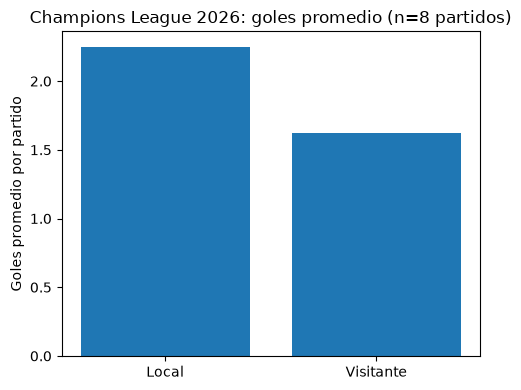

In [15]:
import matplotlib.pyplot as plt

promedios = [resumen["promedio_goles_local"], resumen["promedio_goles_visitante"]]
etiquetas = ["Local", "Visitante"]

plt.figure(figsize=(5, 4))
plt.bar(etiquetas, promedios)
plt.ylabel("Goles promedio por partido")
plt.title(f"Champions League 2026: goles promedio (n={resumen['partidos_finalizados']} partidos)")
plt.tight_layout()
plt.savefig("../docs/goles_local_vs_visitante.png", dpi=150)
plt.show()

**Interpretación:** con los primeros 8 partidos finalizados de la fase de
liga 2026, el equipo local anotó en promedio 2.25 goles por partido contra
1.62 del visitante, consistente con la ventaja de local documentada en
fútbol de clubes. La muestra es todavía pequeña (la temporada acaba de
comenzar), por lo que esta cifra se debe tratar como preliminar: se espera
que este análisis se repita con más partidos en el segundo parcial, y
compararlo contra el historial de finales para ver si el patrón se
mantiene en las instancias decisivas del torneo.